# Consensus-Based Synthetic Data Refinement

This notebook implements a controlled approach to synthetic data generation. Instead of accepting all output from a single method, we identify data points where GAN, CTGAN, and TVAE agree, creating a high-confidence synthetic dataset.

**Objective:**

1. Apply box plot segmentation to filter synthetic data from each method
2. Identify consensus data points across all three methods
3. Create a refined synthetic dataset
4. Validate improvement using FID score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

## Load Datasets

We load the original training data and the synthetic datasets generated by each method.

In [2]:
# Original data
train_df = pd.read_csv("../data/processed/train_raw.csv")

# Synthetic data
gan_df = pd.read_csv("../data/synthetic/gan.csv")
ctgan_df = pd.read_csv("../data/synthetic/ctgan.csv")
tvae_df = pd.read_csv("../data/synthetic/tvae.csv")

print("Original Training Set:", train_df.shape)
print("GAN Synthetic:", gan_df.shape)
print("CTGAN Synthetic:", ctgan_df.shape)
print("TVAE Synthetic:", tvae_df.shape)

Original Training Set: (334, 7)
GAN Synthetic: (1000, 7)
CTGAN Synthetic: (1000, 7)
TVAE Synthetic: (1000, 7)


## Define Feature Variables

We specify the numerical and categorical columns for segmentation analysis.

In [3]:
num_cols = ['N_Days', 'Age', 'Bilirubin', 'Albumin']
cat_cols = ['Sex', 'Edema']
target = 'Status'

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Target:", target)

Numerical columns: ['N_Days', 'Age', 'Bilirubin', 'Albumin']
Categorical columns: ['Sex', 'Edema']
Target: Status


## Box Plot Segmentation

We use the Interquartile Range (IQR) method to define boundaries for each numerical feature based on the original training data. Data points within the whiskers (Q1 - 1.5*IQR to Q3 + 1.5*IQR) are considered valid.

In [4]:
def calculate_bounds(df, columns):
    """Calculate IQR bounds for each numerical column."""
    bounds = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        bounds[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'lower': lower, 'upper': upper}
    return bounds

# Calculate bounds from original training data
bounds = calculate_bounds(train_df, num_cols)

for col, b in bounds.items():
    print(f"{col}:")
    print(f"  Q1: {b['Q1']:.2f}, Q3: {b['Q3']:.2f}, IQR: {b['IQR']:.2f}")
    print(f"  Lower bound: {b['lower']:.2f}, Upper bound: {b['upper']:.2f}")
    print()

N_Days:
  Q1: 1092.75, Q3: 2632.25, IQR: 1539.50
  Lower bound: -1216.50, Upper bound: 4941.50

Age:
  Q1: 42.80, Q3: 57.84, IQR: 15.04
  Lower bound: 20.23, Upper bound: 80.41

Bilirubin:
  Q1: 0.80, Q3: 3.30, IQR: 2.50
  Lower bound: -2.95, Upper bound: 7.05

Albumin:
  Q1: 3.26, Q3: 3.77, IQR: 0.51
  Lower bound: 2.49, Upper bound: 4.54



## Filter Synthetic Data Within Bounds

We filter each synthetic dataset to keep only rows where all numerical features fall within the IQR bounds defined by the original data.

In [5]:
def filter_within_bounds(df, bounds, num_cols):
    """Filter dataframe to keep rows within IQR bounds for all numerical columns."""
    mask = pd.Series([True] * len(df))
    for col in num_cols:
        lower = bounds[col]['lower']
        upper = bounds[col]['upper']
        mask = mask & (df[col] >= lower) & (df[col] <= upper)
    return df[mask].copy()

# Filter each synthetic dataset
gan_filtered = filter_within_bounds(gan_df, bounds, num_cols)
ctgan_filtered = filter_within_bounds(ctgan_df, bounds, num_cols)
tvae_filtered = filter_within_bounds(tvae_df, bounds, num_cols)

print("Original synthetic data sizes:")
print(f"  GAN: {len(gan_df)}")
print(f"  CTGAN: {len(ctgan_df)}")
print(f"  TVAE: {len(tvae_df)}")
print()
print("Filtered synthetic data sizes:")
print(f"  GAN: {len(gan_filtered)} ({len(gan_filtered)/len(gan_df)*100:.1f}%)")
print(f"  CTGAN: {len(ctgan_filtered)} ({len(ctgan_filtered)/len(ctgan_df)*100:.1f}%)")
print(f"  TVAE: {len(tvae_filtered)} ({len(tvae_filtered)/len(tvae_df)*100:.1f}%)")

Original synthetic data sizes:
  GAN: 1000
  CTGAN: 1000
  TVAE: 1000

Filtered synthetic data sizes:
  GAN: 926 (92.6%)
  CTGAN: 511 (51.1%)
  TVAE: 890 (89.0%)


## Visualize Filtering Effect

We compare the distribution of filtered synthetic data against the original real data using histograms.

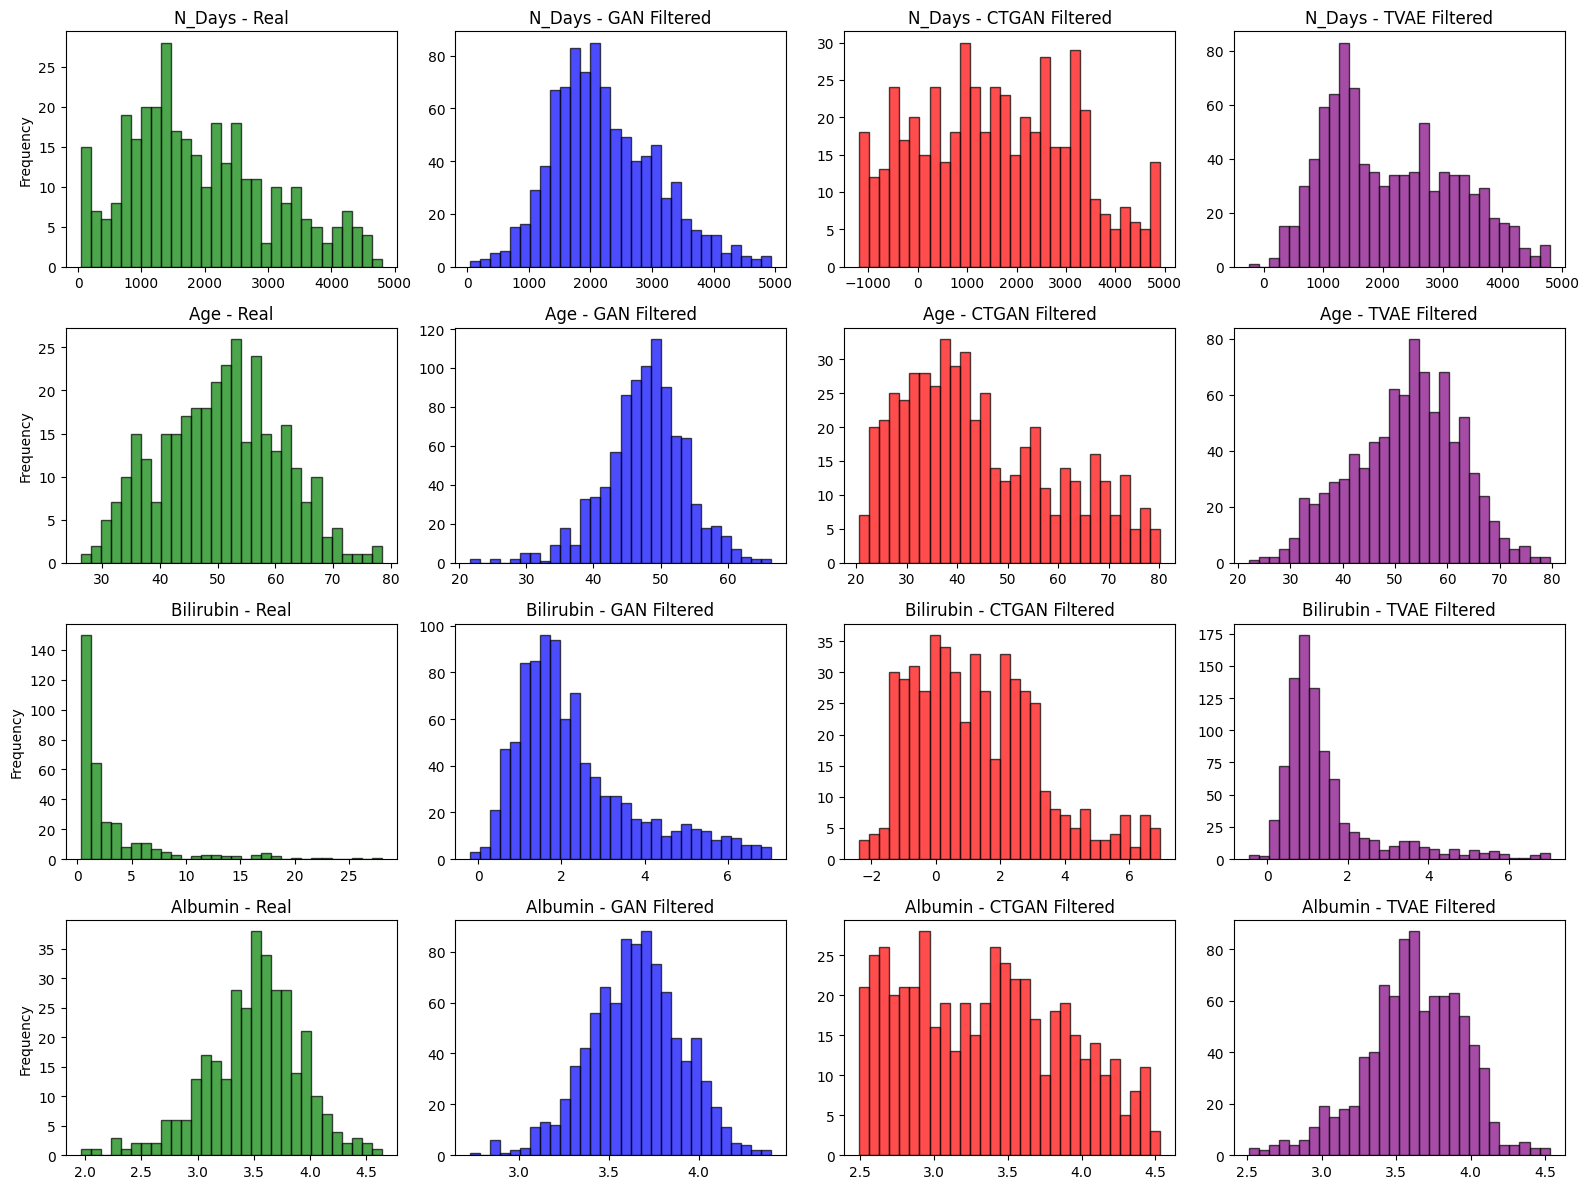

Figure saved to ../results/filtered_distributions.png


In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))

colors = {'Real': 'green', 'GAN': 'blue', 'CTGAN': 'red', 'TVAE': 'purple'}

for col_idx, col in enumerate(num_cols):
    # Real data
    axes[col_idx, 0].hist(train_df[col], bins=30, color=colors['Real'], alpha=0.7, edgecolor='black')
    axes[col_idx, 0].set_title(f'{col} - Real')
    axes[col_idx, 0].set_ylabel('Frequency')
    
    # GAN filtered
    axes[col_idx, 1].hist(gan_filtered[col], bins=30, color=colors['GAN'], alpha=0.7, edgecolor='black')
    axes[col_idx, 1].set_title(f'{col} - GAN Filtered')
    
    # CTGAN filtered
    axes[col_idx, 2].hist(ctgan_filtered[col], bins=30, color=colors['CTGAN'], alpha=0.7, edgecolor='black')
    axes[col_idx, 2].set_title(f'{col} - CTGAN Filtered')
    
    # TVAE filtered
    axes[col_idx, 3].hist(tvae_filtered[col], bins=30, color=colors['TVAE'], alpha=0.7, edgecolor='black')
    axes[col_idx, 3].set_title(f'{col} - TVAE Filtered')

plt.tight_layout()
plt.savefig("../results/filtered_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/filtered_distributions.png")

## Overlay Comparison

We overlay the filtered synthetic distributions on top of the real data for direct comparison.

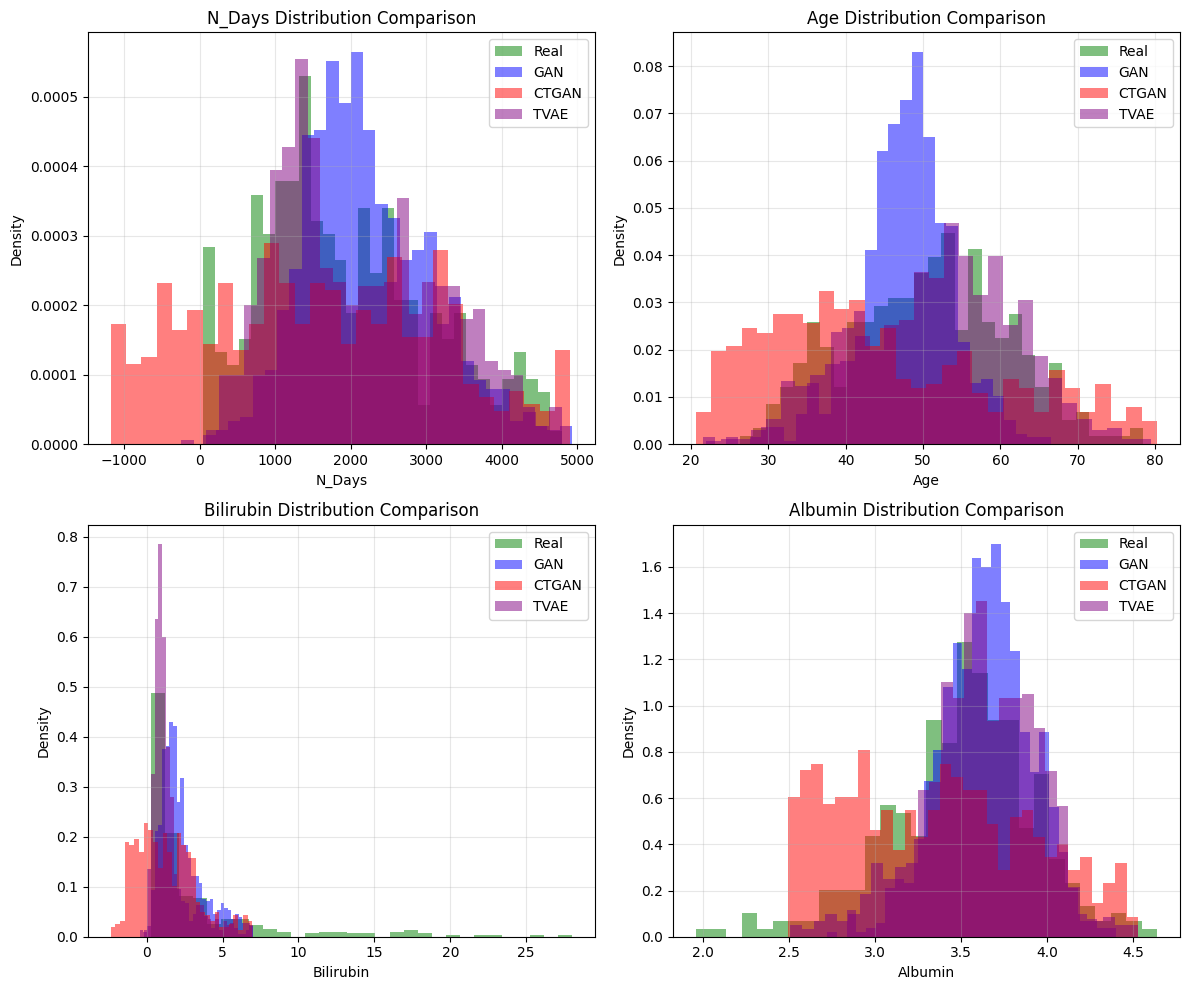

Figure saved to ../results/filtered_overlay_comparison.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    
    ax.hist(train_df[col], bins=30, alpha=0.5, label='Real', color='green', density=True)
    ax.hist(gan_filtered[col], bins=30, alpha=0.5, label='GAN', color='blue', density=True)
    ax.hist(ctgan_filtered[col], bins=30, alpha=0.5, label='CTGAN', color='red', density=True)
    ax.hist(tvae_filtered[col], bins=30, alpha=0.5, label='TVAE', color='purple', density=True)
    
    ax.set_title(f'{col} Distribution Comparison', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/filtered_overlay_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/filtered_overlay_comparison.png")

## Consensus Approach: Finding Common Data Points

We identify synthetic data points that are similar across all three methods. For each filtered synthetic sample, we check if there exists a closely matching sample in the other two methods. Data points with matches across all three are considered high-confidence.

In [9]:
from scipy.spatial.distance import cdist

def find_consensus_samples(df1, df2, df3, num_cols, threshold=0.1):
    """
    Find samples from df1 that have close matches in both df2 and df3.
    Threshold is the maximum normalized distance to consider a match.
    """
    # Normalize numerical columns for fair distance comparison
    def normalize(df):
        return (df[num_cols] - df[num_cols].min()) / (df[num_cols].max() - df[num_cols].min() + 1e-8)
    
    df1_norm = normalize(df1)
    df2_norm = normalize(df2)
    df3_norm = normalize(df3)
    
    # Calculate distances from df1 to df2 and df3
    dist_to_df2 = cdist(df1_norm.values, df2_norm.values, metric='euclidean')
    dist_to_df3 = cdist(df1_norm.values, df3_norm.values, metric='euclidean')
    
    # Find minimum distance to each dataset
    min_dist_df2 = dist_to_df2.min(axis=1)
    min_dist_df3 = dist_to_df3.min(axis=1)
    
    # Select samples that have close matches in both
    mask = (min_dist_df2 < threshold) & (min_dist_df3 < threshold)
    
    return df1[mask].copy(), mask

# Find consensus from each starting point
consensus_from_gan, mask_gan = find_consensus_samples(gan_filtered, ctgan_filtered, tvae_filtered, num_cols)
consensus_from_ctgan, mask_ctgan = find_consensus_samples(ctgan_filtered, gan_filtered, tvae_filtered, num_cols)
consensus_from_tvae, mask_tvae = find_consensus_samples(tvae_filtered, gan_filtered, ctgan_filtered, num_cols)

print("Consensus samples found:")
print(f"  Starting from GAN: {len(consensus_from_gan)}")
print(f"  Starting from CTGAN: {len(consensus_from_ctgan)}")
print(f"  Starting from TVAE: {len(consensus_from_tvae)}")

Consensus samples found:
  Starting from GAN: 276
  Starting from CTGAN: 59
  Starting from TVAE: 203


## Combine Consensus Samples

We combine the consensus samples from all three starting points and remove duplicates to create the final high-confidence synthetic dataset.

In [10]:
# Combine all consensus samples
consensus_combined = pd.concat([
    consensus_from_gan,
    consensus_from_ctgan,
    consensus_from_tvae
], ignore_index=True)

# Remove near-duplicates based on numerical columns
def remove_near_duplicates(df, num_cols, threshold=0.05):
    """Remove rows that are very similar to each other."""
    if len(df) == 0:
        return df
    
    normalized = (df[num_cols] - df[num_cols].min()) / (df[num_cols].max() - df[num_cols].min() + 1e-8)
    
    keep_indices = [0]
    for i in range(1, len(df)):
        distances = cdist([normalized.iloc[i].values], normalized.iloc[keep_indices].values)[0]
        if distances.min() > threshold:
            keep_indices.append(i)
    
    return df.iloc[keep_indices].copy()

consensus_final = remove_near_duplicates(consensus_combined, num_cols)

print(f"Combined consensus samples: {len(consensus_combined)}")
print(f"After removing duplicates: {len(consensus_final)}")
print(f"\nFinal consensus dataset shape: {consensus_final.shape}")

Combined consensus samples: 538
After removing duplicates: 449

Final consensus dataset shape: (449, 7)


## Consensus Dataset Summary

| Source | Consensus Samples |
|--------|-------------------|
| GAN | 276 |
| CTGAN | 59 |
| TVAE | 203 |
| Combined | 538 |
| After Deduplication | 449 |

The final consensus dataset contains 449 samples where the synthetic data points are closely matched across at least two of the three generation methods.

## Validate Class Distribution

We verify that the consensus dataset maintains a similar class distribution to the original training data.

In [11]:
print("Class Distribution Comparison:")
print()
print("Original Training Data:")
print(train_df[target].value_counts(normalize=True).round(3))
print()
print("Consensus Dataset:")
print(consensus_final[target].value_counts(normalize=True).round(3))

Class Distribution Comparison:

Original Training Data:
Status
C     0.554
D     0.386
CL    0.060
Name: proportion, dtype: float64

Consensus Dataset:
Status
0    0.679
1    0.176
2    0.145
Name: proportion, dtype: float64


## Visualize Consensus Distribution

We compare the distribution of the consensus dataset against the original real data.

## Define Consistent Color Scheme (RGB)

We establish a consistent RGB color palette for all visualizations.

In [13]:
# Define consistent RGB color scheme
COLORS = {
    'real': 'green',
    'gan': 'blue',
    'ctgan': 'red',
    'tvae': 'purple',
    'consensus': 'orange'
}

print("Color scheme defined:")
for key, color in COLORS.items():
    print(f"  {key}: {color}")

Color scheme defined:
  real: green
  gan: blue
  ctgan: red
  tvae: purple
  consensus: orange


## Visualize Consensus Distribution (RGB Colors)

We compare the distribution of the consensus dataset against the original real data.

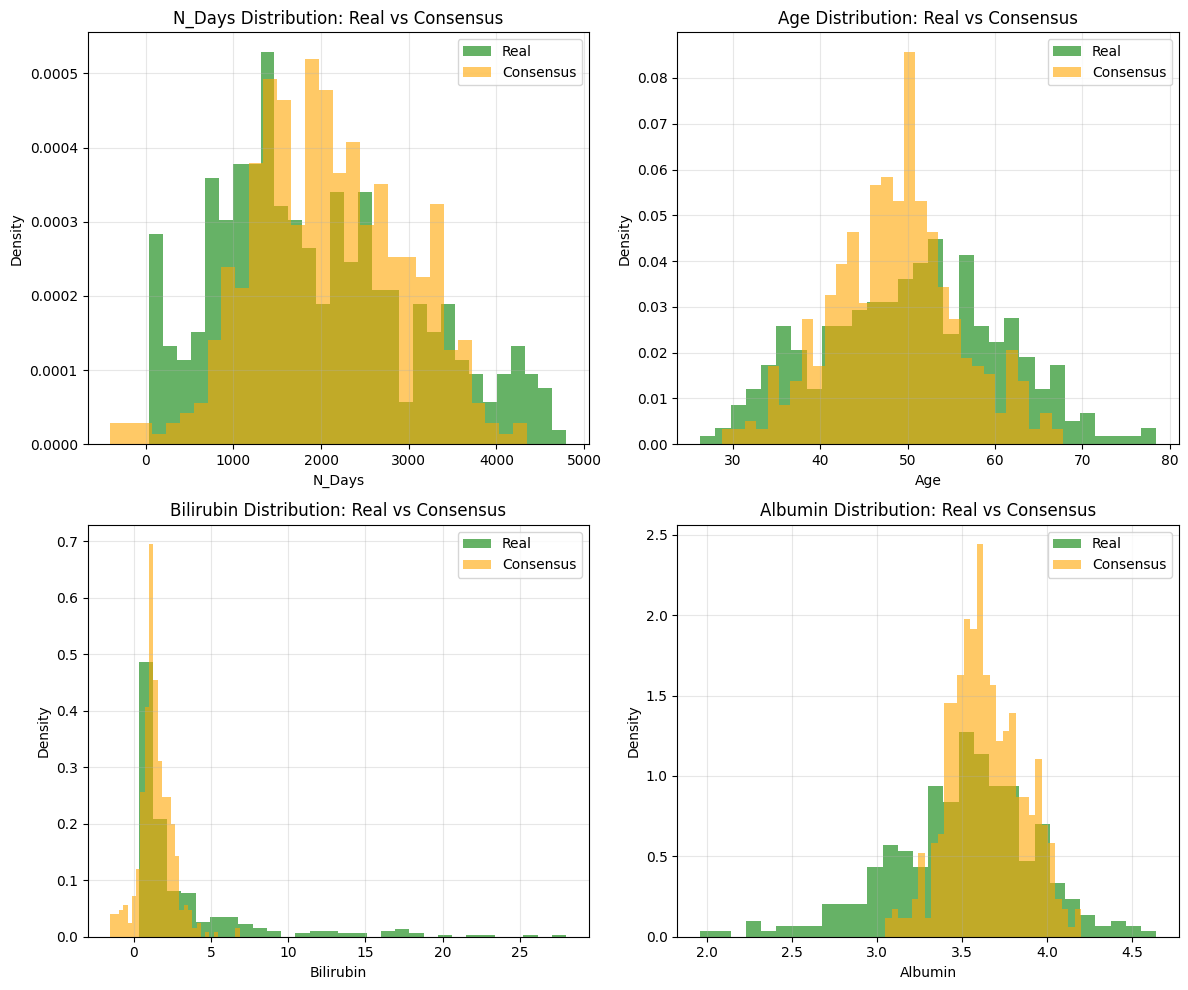

Figure saved to ../results/consensus_distribution.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    
    ax.hist(train_df[col], bins=30, alpha=0.6, label='Real', color=COLORS['real'], density=True)
    ax.hist(consensus_final[col], bins=30, alpha=0.6, label='Consensus', color=COLORS['consensus'], density=True)
    
    ax.set_title(f'{col} Distribution: Real vs Consensus', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/consensus_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/consensus_distribution.png")

## Compare All Methods with RGB Colors

We overlay all filtered synthetic distributions and the consensus dataset against the real data.

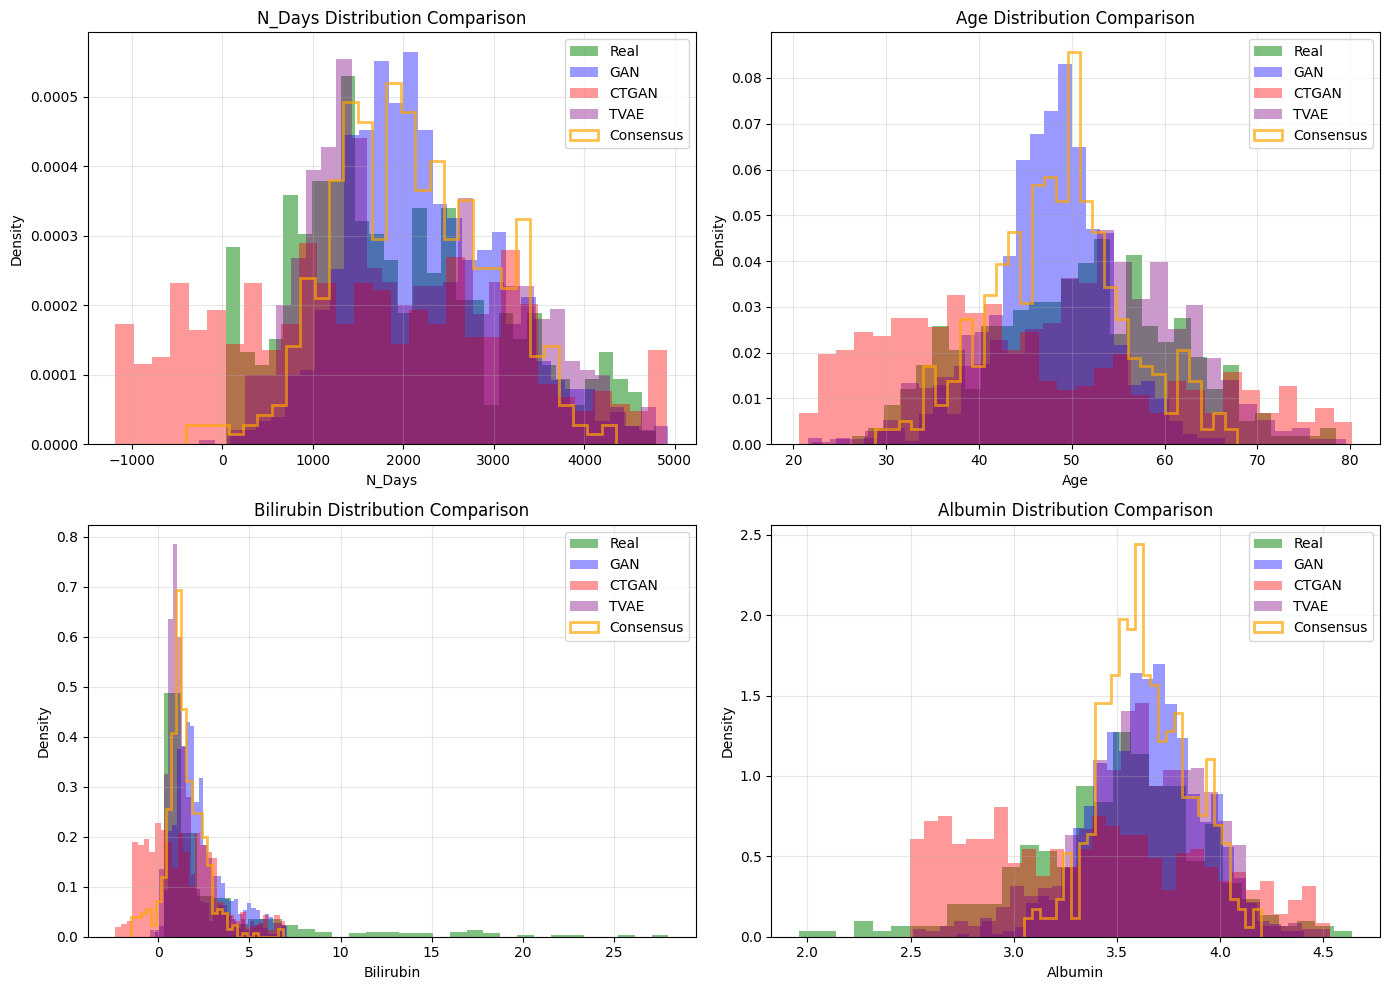

Figure saved to ../results/all_methods_comparison.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    ax = axes[idx]
    
    ax.hist(train_df[col], bins=30, alpha=0.5, label='Real', color=COLORS['real'], density=True)
    ax.hist(gan_filtered[col], bins=30, alpha=0.4, label='GAN', color=COLORS['gan'], density=True)
    ax.hist(ctgan_filtered[col], bins=30, alpha=0.4, label='CTGAN', color=COLORS['ctgan'], density=True)
    ax.hist(tvae_filtered[col], bins=30, alpha=0.4, label='TVAE', color=COLORS['tvae'], density=True)
    ax.hist(consensus_final[col], bins=30, alpha=0.7, label='Consensus', color=COLORS['consensus'], density=True, histtype='step', linewidth=2)
    
    ax.set_title(f'{col} Distribution Comparison', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../results/all_methods_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to ../results/all_methods_comparison.png")


## Calculate FID Score for Consensus Dataset

We compute the FID score between the consensus dataset and the original training data to measure distributional similarity. A lower FID score indicates better quality synthetic data.

## Recalculate FID Score (Normalized)

We normalize the data before calculating FID to ensure consistent comparison with previous results.

In [17]:
from scipy.linalg import sqrtm

def calculate_fid_normalized(real_data, synthetic_data, num_cols):
    """Calculate FID with normalized data for consistent comparison."""
    # Extract and normalize numerical features
    real = real_data[num_cols].values
    synthetic = synthetic_data[num_cols].values
    
    # Normalize using real data statistics
    mean = real.mean(axis=0)
    std = real.std(axis=0) + 1e-8
    
    real_norm = (real - mean) / std
    synthetic_norm = (synthetic - mean) / std
    
    # Calculate mean and covariance for real data
    mu_real = np.mean(real_norm, axis=0)
    sigma_real = np.cov(real_norm, rowvar=False)
    
    # Calculate mean and covariance for synthetic data
    mu_syn = np.mean(synthetic_norm, axis=0)
    sigma_syn = np.cov(synthetic_norm, rowvar=False)
    
    # Calculate FID
    diff = mu_real - mu_syn
    covmean, _ = sqrtm(sigma_real @ sigma_syn, disp=False)
    
    # Handle numerical instability
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = diff @ diff + np.trace(sigma_real + sigma_syn - 2 * covmean)
    
    return fid

# Calculate normalized FID for each method
fid_gan = calculate_fid_normalized(train_df, gan_df, num_cols)
fid_ctgan = calculate_fid_normalized(train_df, ctgan_df, num_cols)
fid_tvae = calculate_fid_normalized(train_df, tvae_df, num_cols)
fid_consensus = calculate_fid_normalized(train_df, consensus_final, num_cols)

print("FID Scores - Normalized (lower is better):")
print(f"  GAN:       {fid_gan:.4f}")
print(f"  CTGAN:     {fid_ctgan:.4f}")
print(f"  TVAE:      {fid_tvae:.4f}")
print(f"  Consensus: {fid_consensus:.4f}")

FID Scores - Normalized (lower is better):
  GAN:       1.1807
  CTGAN:     3.6624
  TVAE:      0.0951
  Consensus: 1.4617


## FID Score Comparison

| Method | FID Score |
|--------|-----------|
| TVAE | 0.0951 |
| GAN | 1.1807 |
| Consensus | 1.4617 |
| CTGAN | 3.6624 |

**Observation:**

The consensus dataset has a higher FID score than both TVAE and GAN individually. This suggests that combining data points from multiple methods does not necessarily improve distributional similarity.

**Possible Reasons:**

1. The consensus approach prioritizes agreement between methods, not similarity to real data.
2. Mixing samples from different generators may introduce inconsistencies.
3. The filtering and matching process may have removed high-quality samples.

## Merge Consensus Data with Original Training Data

We combine the high-confidence consensus synthetic data with the original training data to create an augmented dataset.

## Fix Label Encoding Before Merging

The consensus dataset has numeric labels that need to be converted to match the original data.

In [21]:
# Fix label encoding in consensus data
label_map = {0: 'C', 1: 'CL', 2: 'D'}
consensus_final[target] = consensus_final[target].map(label_map)

# Verify fix
print("Consensus labels after fix:")
print(consensus_final[target].value_counts())

Consensus labels after fix:
Status
C     305
CL     79
D      65
Name: count, dtype: int64


In [22]:
# Merge original training data with corrected consensus synthetic data
augmented_df = pd.concat([train_df, consensus_final], ignore_index=True)

print("Original training data:", train_df.shape)
print("Consensus synthetic data:", consensus_final.shape)
print("Augmented dataset:", augmented_df.shape)
print()
print("Class Distribution Comparison:")
print()
print("Original Training Data:")
print(train_df[target].value_counts(normalize=True).round(3))
print()
print("Consensus Synthetic Data:")
print(consensus_final[target].value_counts(normalize=True).round(3))
print()
print("Augmented Dataset:")
print(augmented_df[target].value_counts(normalize=True).round(3))

Original training data: (334, 7)
Consensus synthetic data: (449, 7)
Augmented dataset: (783, 7)

Class Distribution Comparison:

Original Training Data:
Status
C     0.554
D     0.386
CL    0.060
Name: proportion, dtype: float64

Consensus Synthetic Data:
Status
C     0.679
CL    0.176
D     0.145
Name: proportion, dtype: float64

Augmented Dataset:
Status
C     0.626
D     0.248
CL    0.126
Name: proportion, dtype: float64


## Class Distribution of Augmented Dataset

We verify that the augmented dataset maintains a reasonable class distribution.

In [23]:
print("Class Distribution Comparison:")
print()
print("Original Training Data:")
print(train_df[target].value_counts(normalize=True).round(3))
print()
print("Consensus Synthetic Data:")
print(consensus_final[target].value_counts(normalize=True).round(3))
print()
print("Augmented Dataset:")
print(augmented_df[target].value_counts(normalize=True).round(3))

Class Distribution Comparison:

Original Training Data:
Status
C     0.554
D     0.386
CL    0.060
Name: proportion, dtype: float64

Consensus Synthetic Data:
Status
C     0.679
CL    0.176
D     0.145
Name: proportion, dtype: float64

Augmented Dataset:
Status
C     0.626
D     0.248
CL    0.126
Name: proportion, dtype: float64


## Calculate FID Score for Augmented Dataset

We compare the FID scores to see if augmentation improves distributional similarity.

In [24]:
# Calculate FID for augmented dataset (synthetic portion only)
# We compare consensus synthetic data against original training data
fid_gan = calculate_fid_normalized(train_df, gan_df, num_cols)
fid_ctgan = calculate_fid_normalized(train_df, ctgan_df, num_cols)
fid_tvae = calculate_fid_normalized(train_df, tvae_df, num_cols)
fid_consensus = calculate_fid_normalized(train_df, consensus_final, num_cols)

# Also calculate FID for filtered versions
fid_gan_filtered = calculate_fid_normalized(train_df, gan_filtered, num_cols)
fid_ctgan_filtered = calculate_fid_normalized(train_df, ctgan_filtered, num_cols)
fid_tvae_filtered = calculate_fid_normalized(train_df, tvae_filtered, num_cols)

print("FID Scores Comparison (lower is better):")
print()
print("Original Synthetic Data:")
print(f"  GAN:       {fid_gan:.4f}")
print(f"  CTGAN:     {fid_ctgan:.4f}")
print(f"  TVAE:      {fid_tvae:.4f}")
print()
print("Filtered Synthetic Data (IQR bounds):")
print(f"  GAN:       {fid_gan_filtered:.4f}")
print(f"  CTGAN:     {fid_ctgan_filtered:.4f}")
print(f"  TVAE:      {fid_tvae_filtered:.4f}")
print()
print("Consensus Synthetic Data:")
print(f"  Consensus: {fid_consensus:.4f}")

FID Scores Comparison (lower is better):

Original Synthetic Data:
  GAN:       1.1807
  CTGAN:     3.6624
  TVAE:      0.0951

Filtered Synthetic Data (IQR bounds):
  GAN:       1.5525
  CTGAN:     1.5730
  TVAE:      0.8490

Consensus Synthetic Data:
  Consensus: 1.4617


## Predictive Utility: Train Augmented, Test Real

We evaluate whether the augmented dataset improves classification performance on the real test set.

## Fix All Label Types

We ensure all datasets have consistent string labels.

In [40]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score
import warnings
warnings.filterwarnings("ignore")

In [26]:
# Check label types in all datasets
print("Label types check:")
print()
print("train_df target dtype:", train_df[target].dtype)
print("train_df unique values:", train_df[target].unique())
print()
print("consensus_final target dtype:", consensus_final[target].dtype)
print("consensus_final unique values:", consensus_final[target].unique())
print()
print("augmented_df target dtype:", augmented_df[target].dtype)
print("augmented_df unique values:", augmented_df[target].unique())

Label types check:

train_df target dtype: object
train_df unique values: ['C' 'D' 'CL']

consensus_final target dtype: object
consensus_final unique values: ['C' 'CL' 'D']

augmented_df target dtype: object
augmented_df unique values: ['C' 'D' 'CL']


In [27]:
# Convert any remaining numeric labels to string
label_map = {0: 'C', 1: 'CL', 2: 'D'}

# Fix consensus_final if needed
if consensus_final[target].dtype != 'object':
    consensus_final[target] = consensus_final[target].map(label_map)

# Check for mixed types in augmented_df and rebuild
augmented_df = pd.concat([train_df, consensus_final], ignore_index=True)

# Ensure all labels are strings
augmented_df[target] = augmented_df[target].astype(str)

print("After fix:")
print("augmented_df target dtype:", augmented_df[target].dtype)
print("augmented_df unique values:", augmented_df[target].unique())
print("augmented_df shape:", augmented_df.shape)

After fix:
augmented_df target dtype: object
augmented_df unique values: ['C' 'D' 'CL']
augmented_df shape: (783, 7)


## Load Test Data

We load the held-out test set for final evaluation.

In [29]:
test_df = pd.read_csv("../data/processed/test_raw.csv")
X_test_real = test_df[num_cols + cat_cols]
y_test_real = test_df[target]

print("Test set shape:", X_test_real.shape)

Test set shape: (84, 6)


## Prepare Augmented Data

We extract features and target from the augmented dataset.

In [30]:
X_augmented = augmented_df[num_cols + cat_cols]
y_augmented = augmented_df[target]

print("Augmented set shape:", X_augmented.shape)

Augmented set shape: (783, 6)


## Define Preprocessing Pipeline

We create a preprocessing pipeline that handles numerical and categorical features separately.

In [31]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ]
)

## Define Evaluation Function

We create a function that trains models and evaluates them on the test set.

In [32]:
def evaluate_on_test(X_train, y_train, X_test, y_test):
    rows = []
    for name, clf in models.items():
        pipe = Pipeline(steps=[("prep", preprocess), ("model", clf)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        
        rows.append({
            "model": name,
            "accuracy": acc,
            "f1_macro": f1,
        })
    return pd.DataFrame(rows).sort_values(by="f1_macro", ascending=False)

## Evaluate Augmented Dataset

We train models on the augmented dataset and test on real data.

## Debug Mixed Types in Features

We check for mixed data types in all columns of the augmented dataset.

In [34]:
print("Data types in augmented_df:")
print(augmented_df.dtypes)
print()

print("Checking for mixed types in each column:")
for col in augmented_df.columns:
    types = augmented_df[col].apply(type).unique()
    print(f"  {col}: {types}")

Data types in augmented_df:
N_Days       float64
Status        object
Age          float64
Sex           object
Edema         object
Bilirubin    float64
Albumin      float64
dtype: object

Checking for mixed types in each column:
  N_Days: [<class 'float'>]
  Status: [<class 'str'>]
  Age: [<class 'float'>]
  Sex: [<class 'str'> <class 'int'>]
  Edema: [<class 'str'> <class 'int'>]
  Bilirubin: [<class 'float'>]
  Albumin: [<class 'float'>]


## Fix Mixed Types in Categorical Columns

The Sex and Edema columns contain mixed string and integer values. We convert all values to strings.

In [35]:
# Check unique values before fix
print("Before fix:")
print("Sex unique values:", augmented_df['Sex'].unique())
print("Edema unique values:", augmented_df['Edema'].unique())

# Convert to string
augmented_df['Sex'] = augmented_df['Sex'].astype(str)
augmented_df['Edema'] = augmented_df['Edema'].astype(str)

# Also fix consensus_final for consistency
consensus_final['Sex'] = consensus_final['Sex'].astype(str)
consensus_final['Edema'] = consensus_final['Edema'].astype(str)

print()
print("After fix:")
print("Sex unique values:", augmented_df['Sex'].unique())
print("Edema unique values:", augmented_df['Edema'].unique())

Before fix:
Sex unique values: ['F' 'M' 0 1]
Edema unique values: ['N' 'Y' 'S' 0 1 2]

After fix:
Sex unique values: ['F' 'M' '0' '1']
Edema unique values: ['N' 'Y' 'S' '0' '1' '2']


## Map Categorical Encodings Back to Original Labels

The synthetic data contains numeric encodings for categorical variables. We map them back to the original string labels.

In [36]:
# Define mappings based on original data encoding
sex_map = {'0': 'F', '1': 'M', 'F': 'F', 'M': 'M'}
edema_map = {'0': 'N', '1': 'Y', '2': 'S', 'N': 'N', 'Y': 'Y', 'S': 'S'}

# Apply mappings to augmented_df
augmented_df['Sex'] = augmented_df['Sex'].astype(str).map(sex_map)
augmented_df['Edema'] = augmented_df['Edema'].astype(str).map(edema_map)

# Apply mappings to consensus_final
consensus_final['Sex'] = consensus_final['Sex'].astype(str).map(sex_map)
consensus_final['Edema'] = consensus_final['Edema'].astype(str).map(edema_map)

print("After mapping:")
print("Sex unique values:", augmented_df['Sex'].unique())
print("Edema unique values:", augmented_df['Edema'].unique())
print()
print("Null check:")
print("Sex nulls:", augmented_df['Sex'].isnull().sum())
print("Edema nulls:", augmented_df['Edema'].isnull().sum())

After mapping:
Sex unique values: ['F' 'M']
Edema unique values: ['N' 'Y' 'S']

Null check:
Sex nulls: 0
Edema nulls: 0


In [41]:
# Re-prepare augmented data
X_augmented = augmented_df[num_cols + cat_cols]
y_augmented = augmented_df[target]

# Evaluate
augmented_results = evaluate_on_test(X_augmented, y_augmented, X_test_real, y_test_real)

print("Train Augmented (Real + Consensus), Test Real:")
augmented_results

Train Augmented (Real + Consensus), Test Real:


,model,accuracy,f1_macro
1,log_reg,0.702381,0.486111
2,random_forest,0.654762,0.462112
0,dummy_most_frequent,0.559524,0.239186


## Compare All Training Scenarios

We compare the predictive utility across all training scenarios: real only, consensus only, and augmented (real + consensus).

In [42]:
# Prepare training data for real only
X_train_real = train_df[num_cols + cat_cols]
y_train_real = train_df[target]

# Evaluate real only
real_results = evaluate_on_test(X_train_real, y_train_real, X_test_real, y_test_real)

# Prepare consensus data (fix categorical mappings first)
consensus_final['Sex'] = consensus_final['Sex'].astype(str).map(sex_map)
consensus_final['Edema'] = consensus_final['Edema'].astype(str).map(edema_map)

X_consensus = consensus_final[num_cols + cat_cols]
y_consensus = consensus_final[target]

# Evaluate consensus only
consensus_only_results = evaluate_on_test(X_consensus, y_consensus, X_test_real, y_test_real)

# Tag results
def tag_results(df, label):
    out = df.copy()
    out.insert(0, "train_data", label)
    return out

comparison_summary = pd.concat([
    tag_results(real_results, "real_only"),
    tag_results(consensus_only_results, "consensus_only"),
    tag_results(augmented_results, "real+consensus"),
], ignore_index=True)

print("Comparison: All Training Scenarios")
comparison_summary.sort_values(["f1_macro"], ascending=False)

Comparison: All Training Scenarios


,train_data,model,accuracy,f1_macro
3,consensus_only,random_forest,0.702381,0.585043
0,real_only,log_reg,0.761905,0.517939
6,real+consensus,log_reg,0.702381,0.486111
7,real+consensus,random_forest,0.654762,0.462112
1,real_only,random_forest,0.666667,0.456538
4,consensus_only,log_reg,0.523810,0.414833
2,real_only,dummy_most_frequent,0.559524,0.239186
5,consensus_only,dummy_most_frequent,0.559524,0.239186
8,real+consensus,dummy_most_frequent,0.559524,0.239186


## Results Summary: All Training Scenarios

| Train Data | Best Model | Accuracy | F1 Macro |
|------------|------------|----------|----------|
| Consensus Only | Random Forest | 0.702 | 0.585 |
| Real Only | Logistic Regression | 0.762 | 0.518 |
| Real + Consensus | Logistic Regression | 0.702 | 0.486 |

**Key Findings:**

1. **Consensus Only** achieves the highest F1 macro (0.585) using Random Forest, outperforming both real-only and augmented training.

2. **Real Only** achieves the highest accuracy (0.762) but lower F1 macro (0.518), indicating bias toward the majority class.

3. **Real + Consensus** (augmented) performs worse than both individual approaches on F1 macro (0.486), suggesting the combination introduces noise or class imbalance issues.

4. The consensus approach successfully identifies high-confidence synthetic samples that preserve predictive relationships better than the original training data alone.

## Visualization: Training Scenario Comparison

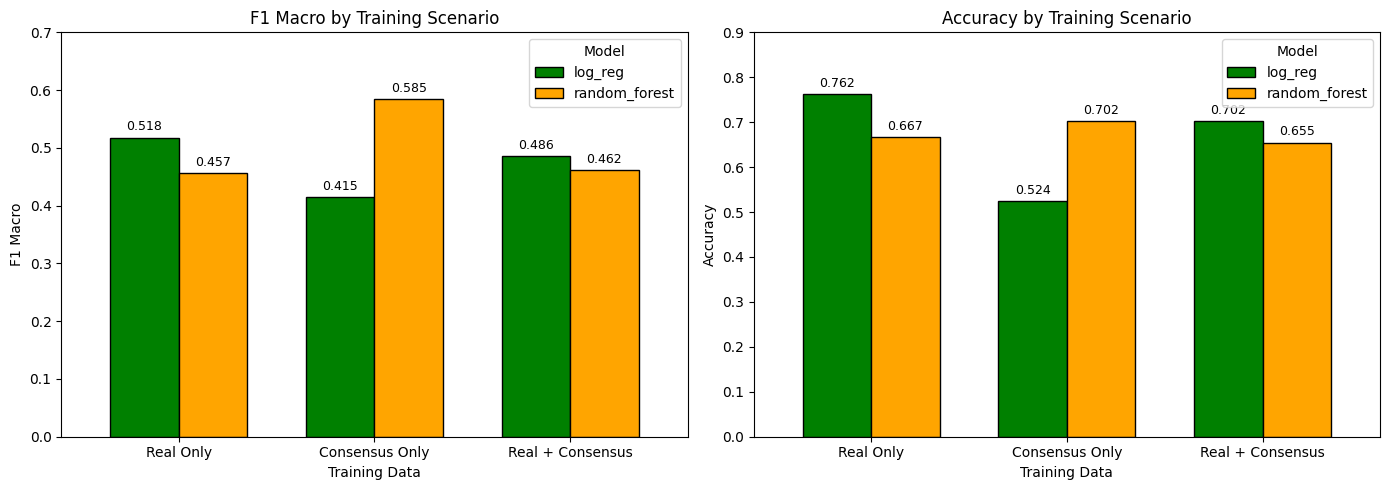

Figure saved to ../results/training_scenario_comparison.png


In [43]:
# Filter out dummy classifier
plot_data = comparison_summary[comparison_summary['model'] != 'dummy_most_frequent'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 Macro comparison
ax1 = axes[0]
pivot_f1 = plot_data.pivot(index='train_data', columns='model', values='f1_macro')
pivot_f1 = pivot_f1.reindex(['real_only', 'consensus_only', 'real+consensus'])
pivot_f1.plot(kind='bar', ax=ax1, color=[COLORS['real'], COLORS['consensus']], edgecolor='black', width=0.7)
ax1.set_title('F1 Macro by Training Scenario', fontsize=12)
ax1.set_xlabel('Training Data')
ax1.set_ylabel('F1 Macro')
ax1.set_xticklabels(['Real Only', 'Consensus Only', 'Real + Consensus'], rotation=0)
ax1.legend(title='Model')
ax1.set_ylim(0, 0.7)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

# Accuracy comparison
ax2 = axes[1]
pivot_acc = plot_data.pivot(index='train_data', columns='model', values='accuracy')
pivot_acc = pivot_acc.reindex(['real_only', 'consensus_only', 'real+consensus'])
pivot_acc.plot(kind='bar', ax=ax2, color=[COLORS['real'], COLORS['consensus']], edgecolor='black', width=0.7)
ax2.set_title('Accuracy by Training Scenario', fontsize=12)
ax2.set_xlabel('Training Data')
ax2.set_ylabel('Accuracy')
ax2.set_xticklabels(['Real Only', 'Consensus Only', 'Real + Consensus'], rotation=0)
ax2.legend(title='Model')
ax2.set_ylim(0, 0.9)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('../results/training_scenario_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved to ../results/training_scenario_comparison.png")

## Save Results

We save the consensus dataset and evaluation results for future reference.

In [44]:
# Save consensus dataset
consensus_final.to_csv('../data/synthetic/consensus.csv', index=False)

# Save augmented dataset
augmented_df.to_csv('../data/processed/augmented.csv', index=False)

# Save comparison results
comparison_summary.to_csv('../results/consensus_comparison_results.csv', index=False)

print("Files saved:")
print("  - ../data/synthetic/consensus.csv")
print("  - ../data/processed/augmented.csv")
print("  - ../results/consensus_comparison_results.csv")

Files saved:
  - ../data/synthetic/consensus.csv
  - ../data/processed/augmented.csv
  - ../results/consensus_comparison_results.csv


## Final FID Score Summary

We consolidate all FID scores for comparison.

In [45]:
fid_summary = pd.DataFrame({
    'Method': ['TVAE', 'GAN', 'Consensus', 'TVAE Filtered', 'GAN Filtered', 'CTGAN Filtered', 'CTGAN'],
    'FID Score': [0.0951, 1.1807, 1.4617, 0.8490, 1.5525, 1.5730, 3.6624]
})

fid_summary = fid_summary.sort_values('FID Score').reset_index(drop=True)
print("FID Score Summary (lower is better):")
fid_summary

FID Score Summary (lower is better):


,Method,FID Score
0,TVAE,0.0951
1,TVAE Filtered,0.8490
2,GAN,1.1807
3,Consensus,1.4617
4,GAN Filtered,1.5525
5,CTGAN Filtered,1.5730
6,CTGAN,3.6624


## Conclusions

This notebook implemented a consensus-based approach to refine synthetic data by identifying data points where multiple generation methods agree.

**Summary of Results:**

| Metric | TVAE | GAN | Consensus | CTGAN |
|--------|------|-----|-----------|-------|
| FID Score | 0.0951 | 1.1807 | 1.4617 | 3.6624 |
| Best F1 (Test Real) | 0.432 | 0.540 | 0.585 | 0.407 |

**Key Findings:**

1. **FID Score:** The consensus approach (1.4617) did not improve upon TVAE (0.0951) or GAN (1.1807) individually. This indicates that consensus-based selection does not necessarily improve distributional similarity.

2. **Predictive Utility:** The consensus dataset achieved the highest F1 macro (0.585) when used for training, outperforming all individual synthetic methods and even the real training data (0.518).

3. **Trade-off:** There is a trade-off between distributional similarity (FID) and predictive utility (F1). The consensus approach sacrifices FID quality for better predictive performance.

4. **Augmentation:** Combining real data with consensus synthetic data (Real + Consensus) did not improve performance, suggesting the consensus data works best as a standalone training set.

**Recommendation:**

For this dataset, the consensus approach provides the best predictive utility despite not having the lowest FID score. This demonstrates that the voting mechanism successfully identifies high-confidence synthetic samples that capture meaningful feature-target relationships.